In [1]:
# W1 EDA: FIFA 22 Player Data
# Goal: Explore which attributes are most strongly associated with wage (within a single year)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('players_22.csv', low_memory=False)

# 1. Basic shape
print("Rows, columns:", df.shape)

# 2. Data types
print("\nData types:\n", df.dtypes.value_counts())

# 3. Missing values
missing = df.isnull().sum()
print("\nColumns with missing values (top 10):\n", missing[missing > 0].sort_values(ascending=False).head(10))

# 4. Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# 5. First 3 rows (just to see structure)
print("\nFirst 3 columns and first 2 rows:\n", df.iloc[:2, :3])

Rows, columns: (19239, 110)

Data types:
 object     50
int64      44
float64    16
Name: count, dtype: int64

Columns with missing values (top 10):
 nation_jersey_number    18480
nation_team_id          18480
nation_position         18480
nation_logo_url         18480
club_loaned_from        18137
player_tags             17798
goalkeeping_speed       17107
player_traits            9841
physic                   2132
defending                2132
dtype: int64



Duplicate rows: 0

First 3 columns and first 2 rows:
    sofifa_id                                         player_url  \
0     158023  https://sofifa.com/player/158023/lionel-messi/...   
1     188545  https://sofifa.com/player/188545/robert-lewand...   

       short_name  
0        L. Messi  
1  R. Lewandowski  


In [2]:
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name',
       'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
       'age',
       ...
       'lcb', 'cb', 'rcb', 'rb', 'gk', 'player_face_url', 'club_logo_url',
       'club_flag_url', 'nation_logo_url', 'nation_flag_url'],
      dtype='object', length=110)

In [3]:
print(df['wage_eur'].head(10))

0    320000.0
1    270000.0
2    270000.0
3    270000.0
4    350000.0
5    130000.0
6    230000.0
7     86000.0
8    250000.0
9    240000.0
Name: wage_eur, dtype: float64


In [4]:
# بيطلع لك الصفوف اللي فيها كل المهارات دي ناقصة مع بعض
missing_all = df[df['pace'].isna() & df['shooting'].isna() & df['passing'].isna()]
print(len(missing_all)) # لو طلع 2132 يبقى هم نفس الصفوف

2132


In [5]:
print(df[df['pace'].isna()]['player_positions'].unique())
# لو النتيجة طلعت ['GK'] بس، يبقى تأكدت إنهم حراس مرمى

['GK']


In [6]:
# Select relevant columns: target (wage_eur) and key attributes
attributes = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
target = 'wage_eur'

# Create a subset DataFrame
df_subset = df[attributes + [target]].copy()

# Check missing values in this subset
print("Missing values per column:\n", df_subset.isnull().sum())

# Option 1: Drop rows with any missing values (MCAR assumption)
df_clean = df_subset.dropna()

print(f"\nRows after dropping missing: {len(df_clean)} (from {len(df_subset)})")

# Compute correlation matrix
corr_matrix = df_clean.corr()

# Show correlations with wage_eur
print("\nCorrelation with wage_eur:\n", corr_matrix[target].sort_values(ascending=False))

Missing values per column:
 pace         2132
shooting     2132
passing      2132
dribbling    2132
defending    2132
physic       2132
wage_eur       61
dtype: int64

Rows after dropping missing: 17054 (from 19239)

Correlation with wage_eur:
 wage_eur     1.000000
passing      0.438336
dribbling    0.421867
shooting     0.312219
physic       0.249843
defending    0.178856
pace         0.134479
Name: wage_eur, dtype: float64


In [7]:
# Define outfield attributes
outfield_attrs = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
gk_attrs = ['goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 
            'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed']
target = 'wage_eur'

# Identify outfield players (non-missing in all outfield_attrs)
outfield_mask = df[outfield_attrs].notna().all(axis=1)
df_outfield = df[outfield_mask].copy()

# Identify goalkeepers (missing in all outfield_attrs - or you could use player_positions containing "GK")
# Using missing pattern: all six outfield attributes are null
gk_mask = df[outfield_attrs].isna().all(axis=1)
df_gk = df[gk_mask].copy()

print(f"Outfield players: {len(df_outfield)}")
print(f"Goalkeepers: {len(df_gk)}")

# Correlations for outfield
corr_outfield = df_outfield[outfield_attrs + [target]].corr()[target].sort_values(ascending=False)
print("\nOutfield - correlation with wage_eur:\n", corr_outfield)

# Correlations for goalkeepers (using GK attributes)
# Note: some GK attributes may have missing values even within GK rows; drop those rows for correlation
df_gk_clean = df_gk[gk_attrs + [target]].dropna()
corr_gk = df_gk_clean[gk_attrs + [target]].corr()[target].sort_values(ascending=False)
print("\nGoalkeepers - correlation with wage_eur:\n", corr_gk)

Outfield players: 17107


Goalkeepers: 2132

Outfield - correlation with wage_eur:
 wage_eur     1.000000
passing      0.438336
dribbling    0.421867
shooting     0.312219
physic       0.249843
defending    0.178856
pace         0.134479
Name: wage_eur, dtype: float64

Goalkeepers - correlation with wage_eur:
 wage_eur                   1.000000
goalkeeping_handling       0.549943
goalkeeping_diving         0.547479
goalkeeping_reflexes       0.544612
goalkeeping_positioning    0.516286
goalkeeping_kicking        0.472407
goalkeeping_speed          0.280131
Name: wage_eur, dtype: float64


In [8]:
df['wage_eur'].min()

500.0

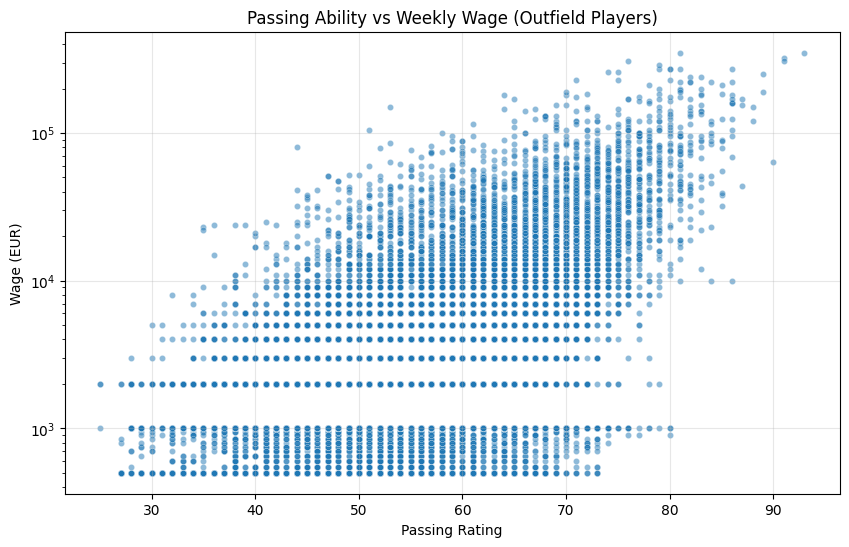

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Outfield players scatter plot: passing vs wage_eur
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_outfield, x='passing', y='wage_eur', alpha=0.5, s=20)
plt.title('Passing Ability vs Weekly Wage (Outfield Players)')
plt.xlabel('Passing Rating')
plt.ylabel('Wage (EUR)')
plt.yscale('log')  # often wages are log-normal; try with and without
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
print(df_outfield['wage_eur'].dtype)
print(df_outfield['wage_eur'].isnull().sum())
print(df_outfield['wage_eur'].nunique())

float64
53
133


In [11]:
# Drop missing wage_eur
df_outfield_clean = df_outfield.dropna(subset=['wage_eur']).copy()

# Create wage categories using pd.cut with quantile bins (avoid qcut edge issues)
# Use percentiles to define low, medium, high
low_thresh = df_outfield_clean['wage_eur'].quantile(0.33)
high_thresh = df_outfield_clean['wage_eur'].quantile(0.67)
bins = [-np.inf, low_thresh, high_thresh, np.inf]
labels = ['low', 'medium', 'high']
df_outfield_clean['wage_category'] = pd.cut(df_outfield_clean['wage_eur'], bins=bins, labels=labels)
df_outfield_clean['wage_category_num'] = df_outfield_clean['wage_category'].map(wage_map)


# Features (same six outfield attributes)
X = df_outfield_clean[outfield_attrs].fillna(df_outfield_clean[outfield_attrs].median())
y = df_outfield_clean['wage_category_num']

# Cleanlab
from cleanlab.classification import CleanLearning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from cleanlab.filter import find_label_issues

clf = RandomForestClassifier(n_estimators=100, random_state=42)
pred_probs = cross_val_predict(clf, X, y, cv=5, method='predict_proba')
label_issues = find_label_issues(labels=y, pred_probs=pred_probs, return_indices_ranked_by='self_confidence')

print(f"Number of potential label issues: {len(label_issues)}")
print("Top 5 flagged players (short_name, actual wage, wage_category):")
for idx in label_issues[:5]:
    print(df_outfield_clean.loc[idx, ['short_name', 'wage_eur', 'wage_category']].to_dict())

NameError: name 'wage_map' is not defined

In [12]:
df_outfield_clean.to_csv('df_outfield_clean.csv', index=False)
df_gk_clean.to_csv('df_gk_clean.csv', index=False)